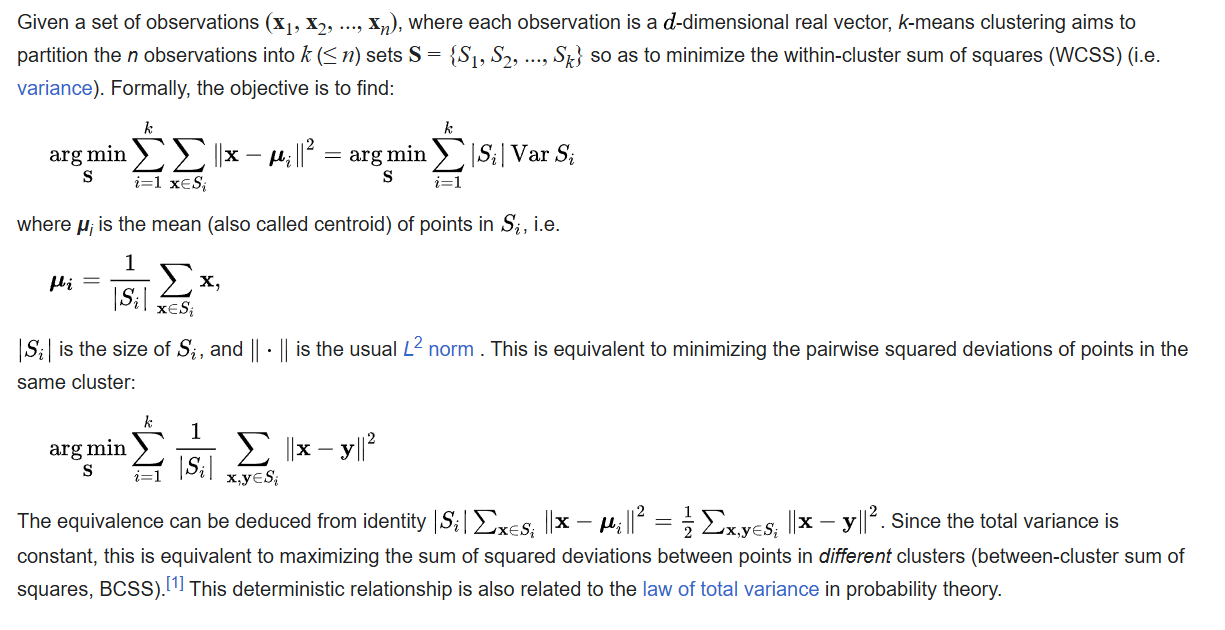

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 

In [ ]:
def find_closest_centroids(X, centroids):
    """
    Computes the centroid  for every example
    
    Args:
        X (ndarray): (m, n) Input values      
        centroids (ndarray): (K, n) centroids
    
    Returns:
        idx (array_like): (m,) closest centroids
    
    """

    # Set K
    K = centroids.shape[0]

    idx = np.zeros(X.shape[0], dtype=int)

    for i in range(X.shape[0]):
        distance =[]

        for j in range(centroids.shape[0]):
            norm_ij = np.linalg.norm(X[i] - centroids[j])
            distance.append(norm_ij)
        
        idx[i] = np.argmin(distance)
    return idx

In [ ]:

def compute_centroids(X, idx, K):
    """
    Returns the new centroids by computing the means of the 
    data points assigned to each centroid.
    
    Args:
        X (ndarray):   (m, n) Data points
        idx (ndarray): (m,) Array containing index of closest centroid for each 
                       example in X. Concretely, idx[i] contains the index of 
                       the centroid closest to example i
        K (int):       number of centroids
    
    Returns:
        centroids (ndarray): (K, n) New centroids computed
    """
    
    m, n = X.shape

    centroids = np.zeros((K, n))
    for k in range(K):
        points = X[idx == k]
        centroids[k] = np.mean(points,axis =0)
    
    return centroids

Below is what happened on each iteration:

---

### Initialization

* **Dataset** $X$ (5 × 2) and **K = 2**.
* **centroids** ← first two points:

  $$
    \mu^{(0)} = 
    \begin{bmatrix}
      1.2 & 3.4\\[6pt]
      2.3 & 4.5
    \end{bmatrix}.
  $$

---

### Iteration 1

1. **Assignment**
   We compute for each $x^{(i)}$ the squared distance to both centroids and pick the smaller:

   | $i$ | $x^{(i)}$  | dist² to $\mu_1$ | dist² to $\mu_2$ | assigned idx |
   | :-: | :--------- | :--------------: | :--------------: | :----------: |
   |  0  | (1.2, 3.4) |       0.00       |       1.56       |       0      |
   |  1  | (2.3, 4.5) |       1.56       |       0.00       |       1      |
   |  2  | (3.1, 1.8) |       2.48       |       2.82       |       0      |
   |  3  | (0.5, 2.2) |       1.39       |       2.92       |       0      |
   |  4  | (4.0, 3.3) |       2.80       |       2.08       |       1      |

   So **idx** = `[0, 1, 0, 0, 1]`.

2. **Update**

   * Cluster 0 has points $\{x^{(1)},x^{(3)},x^{(4)}\}$. Mean = $(1.6,\;2.4667)$.
   * Cluster 1 has points $\{x^{(2)},x^{(5)}\}$. Mean = $(3.15,\;3.9)$.

   New **centroids**:

   $$
     \begin{bmatrix}
       1.6        & 2.4667\\[3pt]
       3.15       & 3.9
     \end{bmatrix}.
   $$

---

### Iteration 2

1. **Assignment** (with updated centroids)
   Recomputing distances yields the **same** assignments `[0, 1, 0, 0, 1]`.

2. **Update**
   Means over each cluster again give exactly $\bigl[\, (1.6,2.4667),\,(3.15,3.9)\bigr]$.

Because centroids didn’t move, the algorithm **converges** at iteration 2.

---

**Final result:**

* **Cluster 0** ($\mu_1=(1.6,2.4667)$) holds points 1, 3, 4.
* **Cluster 1** ($\mu_2=(3.15,3.9)$) holds points 2, 5.


In [ ]:

def run_kMeans(X, initial_centroids, max_iters=10):
    """
    Runs the K-Means algorithm on data matrix X, where each row of X
    is a single example
    """
    
    # Initialize values
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids    
    idx = np.zeros(m)
    plt.figure(figsize=(8, 6))

    # Run K-Means
    for i in range(max_iters):
        
        #Output progress
        print("K-Means iteration %d/%d" % (i, max_iters-1))
        
        # For each example in X, assign it to the closest centroid
        idx = find_closest_centroids(X, centroids)
            
        # Given the memberships, compute new centroids
        centroids = compute_centroids(X, idx, K)
    plt.show() 
    return centroids, idx

In [ ]:
# Random Centroid Selection

def kMeans_init_centroids(X, K):
    """
    This function initializes K centroids that are to be 
    used in K-Means on the dataset X
    
    Args:
        X (ndarray): Data points 
        K (int):     number of centroids/clusters
    
    Returns:
        centroids (ndarray): Initialized centroids
    """
    
    # Randomly reorder the indices of examples
    randidx = np.random.permutation(X.shape[0])
    
    # Take the first K examples as centroids
    centroids = X[randidx[:K]]
    
    return centroids

In [ ]:
X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))

In [ ]:

K = 16
max_iters = 10
 
initial_centroids = kMeans_init_centroids(X_img, K)

# Run K-Means
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters)

In [ ]:
# Find the closest centroid of each pixel
idx = find_closest_centroids(X_img, centroids)

# Replace each pixel with the color of the closest centroid
X_recovered = centroids[idx, :] 

# Reshape image into proper dimensions
X_recovered = np.reshape(X_recovered, original_img.shape) 

In [ ]:
# Display original image
fig, ax = plt.subplots(1,2, figsize=(16,16))
plt.axis('off')

ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].set_axis_off()


# Display compressed image
ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()